## DFT vs. MLIPs Energy Comparison Pipeline

This notebook compares MLIP-predicted energies and forces against DFT reference calculations. For each frame in a DFT trajectory, the MLIP takes the DFT-computed structure (atomic positions, cell) as input and performs a single-point evaluation, predicting E and F(r) for that fixed, pre-relaxed geometry. 

This is used to find adsorption energy (E_ads = E_tot − E_slab − E_gas).

Currently, models used are NEP89, MACE, MatterSim, and UMA (each run by a script in `model-scripts`).

**Directory Setup** \
To run this notebook, make sure your directory structure mimics this:

**See `README` for conda environment setup.**

#### 0. Configuration

In [ ]:
import numpy as np
from ase.io import read, write

import subprocess
import os
import time
from pathlib import Path

In [81]:
# construct data structure used to hold user input
ROOT = "dft-data"

def make_run(path):
    rel = path.parent.name
    return {"run_id": str(rel), "path": str(path)}

def discover_dft_runs():
    root = Path(ROOT)
    runs = []

    for dirpath, dirnames, filenames in os.walk(root):
        current = Path(dirpath)
        if "OUTCAR" in filenames:
            runs.append(make_run(current / "OUTCAR"))
            dirnames[:] = []  # stop descending -- ignore any nested OUTCARs (e.g. FastRelax)

    if not runs:
        raise FileNotFoundError(f"no OUTCAR found under {ROOT}")

    return sorted(runs, key=lambda r: r["run_id"])

def make_model(name, python_bin, script_path,  supported_devices=("mps", "cuda", "cpu", "N/A")):
    return {
        "name":       name,
        "python_bin": python_bin,
        "script":     script_path,
        "supported_devices": list(supported_devices)
    }

In [ ]:
RUNS = discover_dft_runs()

# # print output to check if OUTCARs were read in correctly
# for r in RUNS:
#     print(r["run_id"], "->", r["path"])

In [83]:
# function to set up running model scripts

def conda_python(env_name):
    # resolve env name (eg. 'mlip-mace') to its python binary for the machine this notebook is running on
    out = subprocess.run(['conda', 'env', 'list', '--json'], capture_output=True, text=True)
    import json
    envs = json.loads(out.stdout)['envs']
    for p in envs:
        if p.rstrip('/').endswith(env_name):
            return f"{p}/bin/python"
    raise RuntimeError(f"conda env '{env_name}' not found")

In [84]:
# ================================================
# USER INPUT HERE - edit add new DFT runs & models
# ================================================

# do you want to re-run single-point model evaluations? (note: takes a little time)
RUN_MLIPS = True

# report MLIP calculation wall clock time?
SHOW_TIMING = True

# do you want to read in new DFT data?
#   True:  overwrites files in dft-cache/
#   False: use cached DFT trajectories in model-scripts/dft-cache/
WRITE_DFT_DATA = True

# RUNS: auto-discovered from dft-data/. each run is identified by its folder path
# (relative to dft-data), found by walking the tree and taking the first OUTCAR
# hit in each branch -- if a folder has a direct OUTCAR, nested OUTCARs below
# it (e.g. a FastRelax subfolder) are ignored.
RUNS = discover_dft_runs()

# MODELS: each entry is (display name, path to that model's python interpreter, runner script)
# each mlip lives in its own conda env to avoid dependency conflicts

MODELS = [
    make_model("NEP89",     conda_python("mlip-nep89"),     "model-scripts/run_nep89.py",     ["N/A"]),
    make_model("MACE",      conda_python("mlip-mace"),      "model-scripts/run_mace.py",      ["cuda", "cpu"]),  # mace allegedly supports mps, but you need to fix a bug in the model file first
    make_model("MatterSim", conda_python("mlip-mattersim"), "model-scripts/run_mattersim.py", ["cuda", "cpu"]),
    make_model("UMA",       conda_python("mlip-uma"),       "model-scripts/run_uma.py",       ["cuda", "cpu"]),
]

#### 1. DFT data ingestion

In [85]:
# load vasp trajectories into ASE Atoms obj.

# for trajectory files with multiple steps
def load_frames(path):
    # reads all ionic steps from an OUTCAR file
    return list(read(path, index=":", format="vasp-out"))

# for single-structure files (slab reference, gas reference)
def load_frame(path):
    return read(path, format="vasp-out")

In [ ]:
# run this to read in new DFT data

# converts DFT trajectories -> .xyz files for MLIP runner scripts to read
# writes .xyz output files to hold model results later
MAX_FRAMES = 25  # set sample size here

if WRITE_DFT_DATA:
    from pathlib import Path
    for file in Path("model-scripts/dft-cache/").glob("*"):
        file.unlink()
    for run in RUNS:
        # check number of frames per run, sample accordingly
        frames = load_frames(run["path"])
        indices = np.linspace(0, len(frames)-1, min(MAX_FRAMES, len(frames)), dtype=int)
        sampled = [frames[i] for i in indices]

        cache_path = Path(f"model-scripts/dft-cache/dft_{run["run_id"]}.xyz")
        write(cache_path, sampled)
else:
    print("cell skipped!")

#### 2. run MLIPs (MACE, MatterSim, UMA)

In [87]:
# match best device to run each model on with existing local hardware
# appends 'device' key to MODELS

if RUN_MLIPS:
    import torch

    machine_devices = []
    if torch.backends.mps.is_built() and torch.backends.mps.is_available():
        machine_devices.append("mps")
    if torch.cuda.is_available():
        machine_devices.append("cuda")
    machine_devices.append("cpu")

    for m in MODELS:
        if m['supported_devices'] == ["N/A"]:
            m['device'] = "N/A"  # no device concept for this model
            print(f"{m['name']}: device N/A")
        else:
            m['device'] = next(d for d in machine_devices if d in m["supported_devices"])
            print(f"{m['name']}: {m['device']}")
else:
    print("cell skipped!")

NEP89: device N/A
MACE: cpu
MatterSim: cpu
UMA: cpu


In [88]:
# runs each MLIP runner script as a subprocess using that model's own conda env
# each script reads the .xyz inputs and writes a .npz file (numpy filetype) 
# with predicted E, F(r)

if RUN_MLIPS:
    env = os.environ.copy()
    env['MPLBACKEND'] = "Agg"

    for model in MODELS:
        for run in RUNS:
            rid = run['run_id']
            in_path = f"model-scripts/dft-cache/dft_{rid}.xyz"
            out_path = f"model-scripts/mlip-results/{model['name'].lower()}_{rid}.npz"
            if not Path(out_path).exists():
                Path(out_path).touch()

            t0 = time.perf_counter()
            r = subprocess.run(
                [model['python_bin'], model['script'], in_path, out_path, model['device']],
                capture_output=True, text=True, env=env
            )
            elapsed = time.perf_counter() - t0

            if r.returncode != 0:
                print(f"-- [{rid}] ({model['name']}): failed")
                if r.stdout: print(r.stdout)
                if r.stderr: print(r.stderr)
                print("Return code:", r.returncode)
                raise RuntimeError("Notebook halted.")
            else:
                msg = f"-- [{rid}] ({model['name']}): success"
                if SHOW_TIMING:
                    msg += f" ({elapsed:.2f}s)"
                print(msg)
else:
    print("cell skipped!")

-- [2CO3_Ag2] (NEP89): success (2.24s)
-- [COOH_YO4PdCu_1] (NEP89): success (1.45s)
-- [COOH_YO4PdCu_10] (NEP89): success (1.40s)
-- [COOH_YO4PdCu_11] (NEP89): success (1.48s)
-- [COOH_YO4PdCu_12] (NEP89): success (1.46s)
-- [COOH_YO4PdCu_13] (NEP89): success (1.58s)
-- [COOH_YO4PdCu_14] (NEP89): success (1.50s)
-- [COOH_YO4PdCu_15] (NEP89): success (1.59s)
-- [COOH_YO4PdCu_2] (NEP89): success (1.82s)
-- [COOH_YO4PdCu_3] (NEP89): success (1.57s)
-- [COOH_YO4PdCu_4] (NEP89): success (1.45s)
-- [COOH_YO4PdCu_5] (NEP89): success (1.45s)
-- [COOH_YO4PdCu_6] (NEP89): success (1.48s)
-- [COOH_YO4PdCu_7] (NEP89): success (1.51s)
-- [COOH_YO4PdCu_8] (NEP89): success (1.51s)
-- [COOH_YO4PdCu_9] (NEP89): success (1.46s)
-- [OCCO_Ag5] (NEP89): success (1.42s)
-- [2CO3_Ag2] (MACE): success (10.68s)
-- [COOH_YO4PdCu_1] (MACE): success (17.72s)
-- [COOH_YO4PdCu_10] (MACE): success (12.14s)
-- [COOH_YO4PdCu_11] (MACE): success (16.85s)
-- [COOH_YO4PdCu_12] (MACE): success (16.54s)
-- [COOH_YO4PdCu_13

In [89]:
# (re)populate RUNS without needing to run models again

def run_paths(run):
    rid = run['run_id']
    root = "model-scripts"
    return {
        'dft_cache': f"{root}/dft-cache/dft_{rid}.xyz",
        'results': {
            m['name'].lower(): f"{root}/mlip-results/{m['name'].lower()}_{rid}.npz"
            for m in MODELS
        },
    }

for run in RUNS:
    run.update(run_paths(run))

#### 3. plot results (model E<sub>slab+ads</sub> vs. DFT E<sub>slab+ads</sub>)

In [ ]:
import matplotlib.pyplot as plt
import math
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

# USER INPUT - optionally filter which runs to plot by substring match on run_id
# set either to None to skip that filter
# e.g. SLAB_FILTER = "YPdCu" only plots YPdCu slab runs

ADS_FILTER = None
SLAB_FILTER = None

all_runs = sorted(
    (r for r in RUNS
    if (ADS_FILTER is None or ADS_FILTER in r['run_id'])
    and (SLAB_FILTER is None or SLAB_FILTER in r['run_id'])),
    key=lambda r: r['run_id']
)

In [92]:
# read DFT energies from saved .xyz files into each run dict
# slab_energy and gas_energy are single reference values used to compute E_ads later

for run in RUNS:
    frames = read(run['dft_cache'], index=":")
    run['dft'] = {
        "energies": np.array([a.get_potential_energy() for a in frames]),
    }

Parity line plotted in grey.


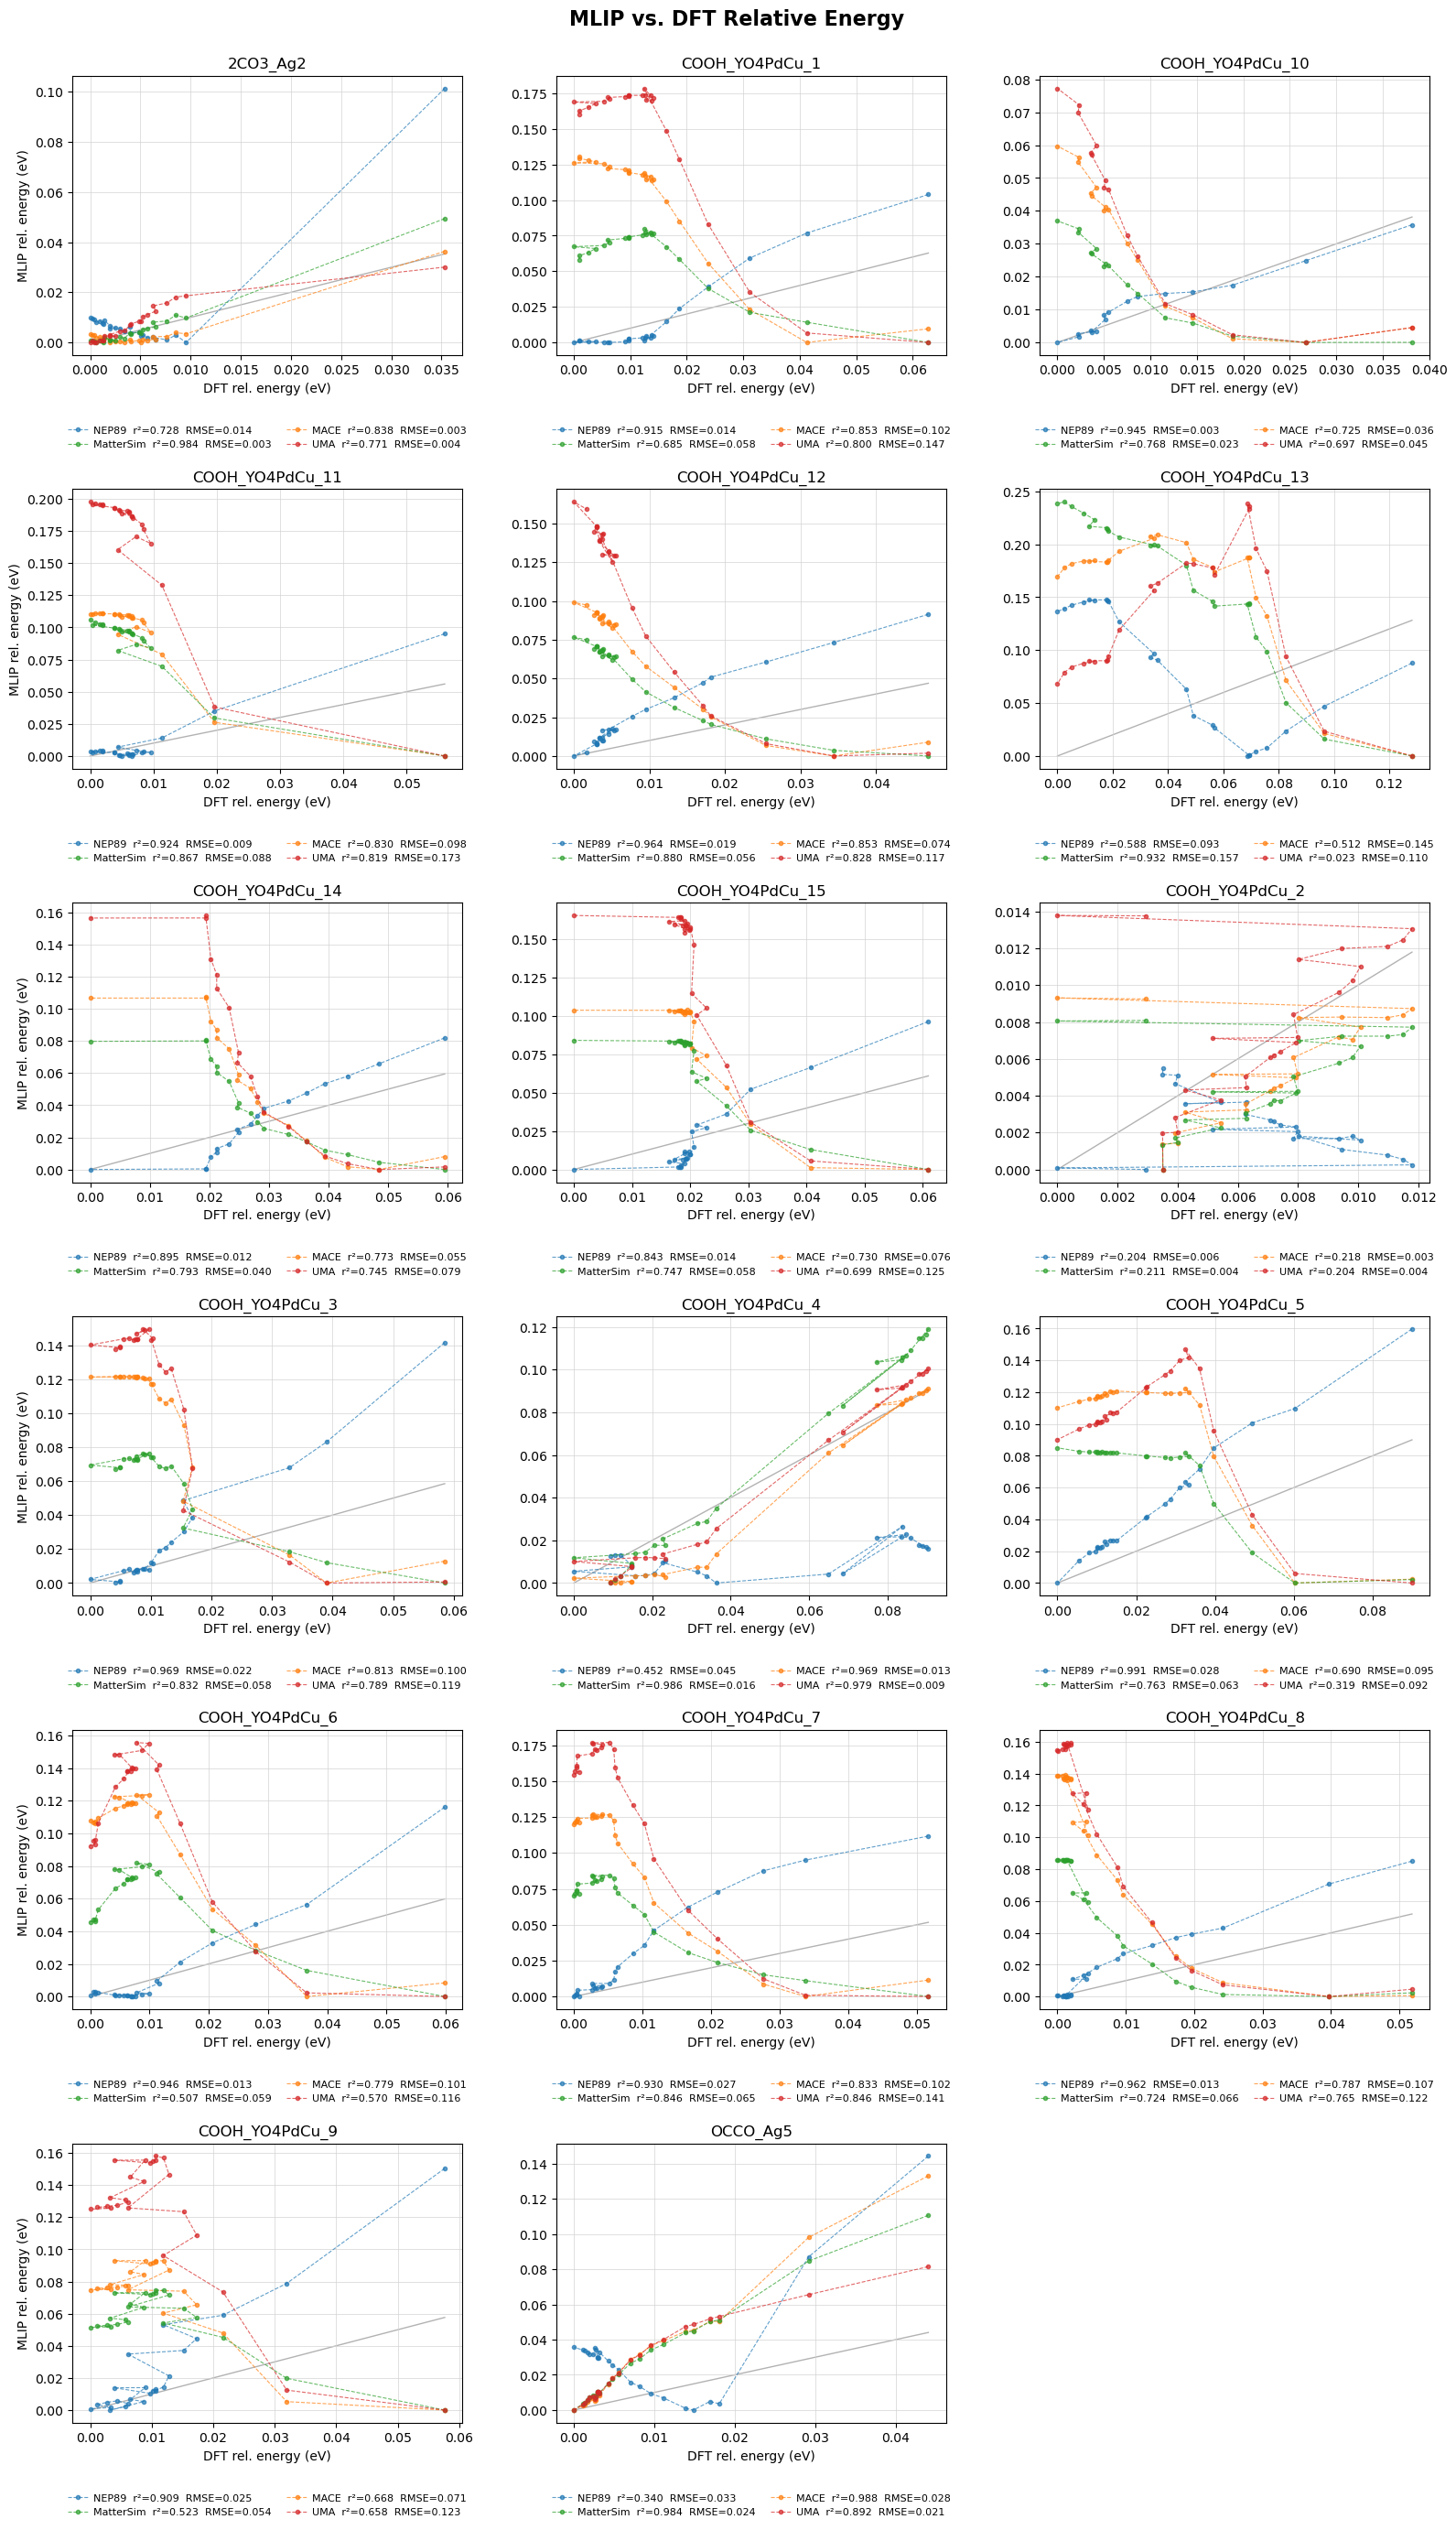

In [ ]:
# --- figure: parity plot, relative energy trajectory by config ---
# MLIP and DFT energies are each relative to their own lowest value

# USER INPUT - select stats displayed on plot:
SHOW_R2   = True
SHOW_RMSE = True

print("Parity line plotted in grey.")

ncols = min(len(all_runs), 3)
nrows = math.ceil(len(all_runs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5.4, nrows*4.9), dpi=100)
axes = np.array(axes).flatten()

fig.suptitle("MLIP vs. DFT Relative Energy", fontsize=16, fontweight='semibold', y=0.96)

for i, run in enumerate(all_runs):
    ax = axes[i]
    dft_e = run['dft']['energies']
    dft_rel = dft_e - dft_e.min()

    # grey parity line (y = x) drawn first so model curves sit on top
    lims = [min(dft_rel.min(), 0), dft_rel.max()]
    ax.plot(lims, lims, color='grey', linestyle='-', lw=1, alpha=0.6, zorder=0)

    for j, model in enumerate(MODELS):
        name = model['name']
        color = plt.cm.tab10(j)
        mlip_e = np.load(run['results'][name.lower()])['mlip_energies']
        mlip_rel = mlip_e - mlip_e.min()

        stats = [name]
        if SHOW_R2:
            r2 = pearsonr(dft_rel, mlip_rel).statistic ** 2
            stats.append(f"r²={r2:.3f}")
        if SHOW_RMSE:
            rmse = np.sqrt(mean_squared_error(dft_rel, mlip_rel))
            stats.append(f"RMSE={rmse:.3f}")

        ax.plot(dft_rel, mlip_rel, '--o', color=color,
                label="  ".join(stats), markersize=3, lw=0.8, alpha=0.7)

    handles, labels = ax.get_legend_handles_labels()
    ncol = 2
    nrow = math.ceil(len(handles) / ncol)
    order = [k for row in range(nrow) for k in range(row, len(handles), nrow)]
    handles = [handles[k] for k in order]
    labels = [labels[k] for k in order]

    leg = ax.legend(handles, labels, fontsize=8, loc='upper center',
                    bbox_to_anchor=(0.5, -0.22), ncol=ncol, frameon=False,
                    columnspacing=1.5, handletextpad=0.5)

    ax.set_title(run['run_id'])
    ax.set_xlabel("DFT rel. energy (eV)")
    ax.grid(color='lightgrey', linewidth=0.5)
    if i % ncols == 0:
        ax.set_ylabel("MLIP rel. energy (eV)")

for ax in axes[len(all_runs):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

In [ ]:
# sanity check on point order: confirm cached DFT .xyz frame order matches OUTCAR frame order.

# for 4 checkpoint frames along trajectory, compares atom positions and
# potential energy between the OUTCAR frame (at its sampled index) and the
# corresponding .xyz frame -- mismatches here would indicate frames got
# shuffled somewhere between DFT read-in and .xyz caching.

idx = 3  # index of run to check in RUNS
run_id = RUNS[idx]["run_id"]  # change index/run_id as needed

outcar_frames = load_frames(RUNS[idx]["path"])
xyz_frames = read(f"model-scripts/dft-cache/dft_{run_id}.xyz", index=":")

# indices used during sampling (must match MAX_FRAMES logic used when cache was written)
idx = np.linspace(0, len(outcar_frames)-1, min(MAX_FRAMES, len(outcar_frames)), dtype=int)

for k in [0, len(idx)//3, 2*len(idx)//3, -1]:
    o = outcar_frames[idx[k]]
    x = xyz_frames[k]
    match = np.allclose(o.positions, x.positions, atol=1e-4)
    print(f"frame {k} (outcar idx {idx[k]}): positions match = {match}, "
            f"E_outcar={o.get_potential_energy():.4f}  E_xyz={x.get_potential_energy():.4f}")

frame 0 (outcar idx 0): positions match = True, E_outcar=-445.0159  E_xyz=-445.0159
frame 8 (outcar idx 63): positions match = True, E_outcar=-445.0654  E_xyz=-445.0654
frame 16 (outcar idx 126): positions match = True, E_outcar=-445.0672  E_xyz=-445.0672
frame -1 (outcar idx 190): positions match = True, E_outcar=-445.0719  E_xyz=-445.0719


run: 2CO3_Ag2



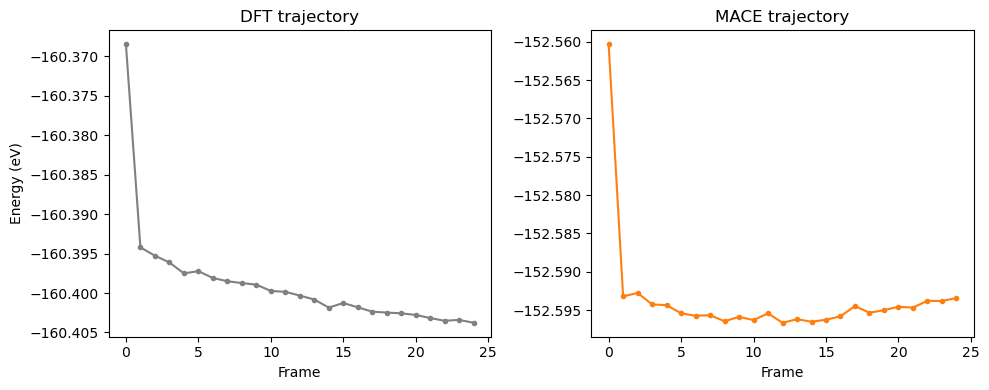

frame      E_dft     E_mlip    dft_rel   mlip_rel
-------------------------------------------------
    0 -160.36846 -152.56032    0.03532    0.03635
    1 -160.39422 -152.59322    0.00956    0.00345
    2 -160.39526 -152.59277    0.00851    0.00389
    3 -160.39612 -152.59427    0.00765    0.00240
    4 -160.39751 -152.59436    0.00626    0.00230
    5 -160.39723 -152.59543    0.00655    0.00124
    6 -160.39809 -152.59575    0.00568    0.00092
    7 -160.39851 -152.59567    0.00527    0.00099
    8 -160.39874 -152.59647    0.00504    0.00020
    9 -160.39894 -152.59589    0.00484    0.00078
   10 -160.39974 -152.59631    0.00404    0.00035
   11 -160.39985 -152.59543    0.00393    0.00124
   12 -160.40032 -152.59666    0.00345    0.00000
   13 -160.40083 -152.59619    0.00295    0.00047
   14 -160.40185 -152.59653    0.00193    0.00014
   15 -160.40126 -152.59627    0.00251    0.00040
   16 -160.40181 -152.59581    0.00196    0.00085
   17 -160.40236 -152.59448    0.00141    0.00218


In [117]:
# print DFT/MLIP absolute and relative (rel. to min) energies per frame,
# matching what's plotted on the parity graph
run_id = RUNS[0]["run_id"]  # change as needed
model_name = "mace"          # change as needed (nep89 / mace / mattersim / uma)

dft_e = read(f"model-scripts/dft-cache/dft_{run_id}.xyz", index=":")
dft_e = np.array([a.get_potential_energy() for a in dft_e])
mlip_e = np.load(f"model-scripts/mlip-results/{model_name}_{run_id}.npz")["mlip_energies"]

dft_rel = dft_e - dft_e.min()
mlip_rel = mlip_e - mlip_e.min()

print(f"run: {run_id}\n")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(dft_e, '-o', color='grey', markersize=3)
axes[0].set_title(f"DFT trajectory")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Energy (eV)")

axes[1].plot(mlip_e, '-o', color='tab:orange', markersize=3)
axes[1].set_title(f"{model_name.upper()} trajectory")
axes[1].set_xlabel("Frame")
axes[1].ticklabel_format(useOffset=False, style='plain')

plt.tight_layout()
plt.show()

header = f"{'frame':>5} {'E_dft':>10} {'E_mlip':>10} {'dft_rel':>10} {'mlip_rel':>10}"
print(header)
print("-" * len(header))
for i, (d, m, dr, mr) in enumerate(zip(dft_e, mlip_e, dft_rel, mlip_rel)):
    print(f"{i:>5} {d:>10.5f} {m:>10.5f} {dr:>10.5f} {mr:>10.5f}")